Import the libraries

In [109]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load the data

In [110]:
df=pd.read_csv('data_of_real_state.csv')
df.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Society,Company Name,Flat Type
0,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4,Outside Socity,Outside,Plot
4,24000000,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3,Anant Raj Estate Plots,Anant,Floor


Explore the data columns datatype

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Price          19515 non-null  str  
 1   Status         19515 non-null  str  
 2   Area           19515 non-null  int64
 3   Rate per sqft  19515 non-null  str  
 4   Property Type  19515 non-null  str  
 5   Locality       19515 non-null  str  
 6   Builder Name   19515 non-null  str  
 7   RERA Approval  19515 non-null  str  
 8   BHK_Count      19515 non-null  int64
 9   Society        19515 non-null  str  
 10  Company Name   19515 non-null  str  
 11  Flat Type      19515 non-null  str  
dtypes: int64(2), str(10)
memory usage: 1.8 MB


Data Cleaning and Preprocessing


In [112]:
# Standardize the columns & replace the columns name into standarize names
df.columns=df.columns.str.strip().str.lower().str.replace(' ','_')
df.columns

Index(['price', 'status', 'area', 'rate_per_sqft', 'property_type', 'locality',
       'builder_name', 'rera_approval', 'bhk_count', 'society', 'company_name',
       'flat_type'],
      dtype='str')

In [113]:
df['price']=df['price'].astype(str).str.replace(',','').astype('Int64')
df['area']=df['area'].astype('Int64')
df['rate_per_sqft']=df['rate_per_sqft'].astype(str).str.replace(',','').astype('Int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   price          19515 non-null  Int64
 1   status         19515 non-null  str  
 2   area           19515 non-null  Int64
 3   rate_per_sqft  19515 non-null  Int64
 4   property_type  19515 non-null  str  
 5   locality       19515 non-null  str  
 6   builder_name   19515 non-null  str  
 7   rera_approval  19515 non-null  str  
 8   bhk_count      19515 non-null  int64
 9   society        19515 non-null  str  
 10  company_name   19515 non-null  str  
 11  flat_type      19515 non-null  str  
dtypes: Int64(3), int64(1), str(8)
memory usage: 1.8 MB


In [114]:
df['rera_approval']=df['rera_approval'].map({'Approved by RERA':True,'Not approved by RERA':False})
df['rera_approval'].head()

0     True
1     True
2     True
3    False
4     True
Name: rera_approval, dtype: bool

In [115]:
df.isnull().sum()

price            0
status           0
area             0
rate_per_sqft    0
property_type    0
locality         0
builder_name     0
rera_approval    0
bhk_count        0
society          0
company_name     0
flat_type        0
dtype: int64

Exploratory Data Analysis

Which locality has the highest average property rice

In [116]:
df.drop_duplicates(inplace=True)

In [117]:
df.shape

(14223, 12)

In [118]:
df.describe()

,price,area,rate_per_sqft,bhk_count
count,14223.0,14223.0,14223.0,14223.000000
mean,39953766.434648,2621.755959,15296.143992,3.266189
std,57552907.991364,11125.298077,18761.002333,5.496692
min,95000.0,60.0,100.0,0.000000
25%,14100000.0,1424.0,8368.0,2.000000
50%,26200000.0,2015.0,12380.0,3.000000
75%,45500000.0,2840.5,18500.0,4.000000
max,1226300000.0,958320.0,310000.0,132.000000


C:\Users\DELL\AppData\Local\Temp\ipykernel_10308\3463918161.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=locality_with_avg_price.index,y=locality_with_avg_price.values,palette='rocket')


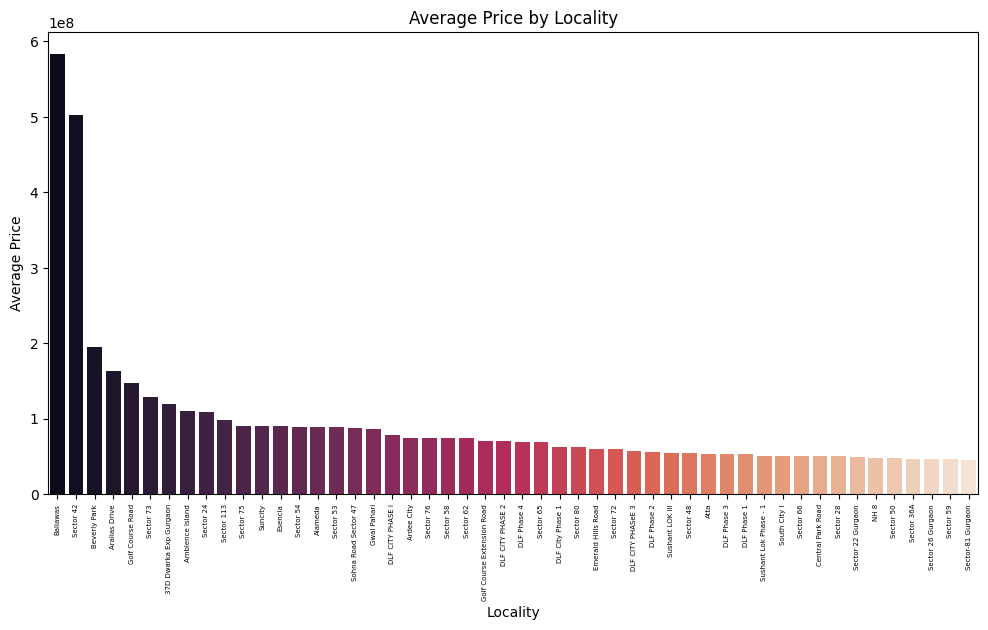

In [119]:
locality_with_avg_price=df.groupby('locality')['price'].mean().sort_values(ascending=False).head(50)
plt.figure(figsize=(12,6))
sns.barplot(x=locality_with_avg_price.index,y=locality_with_avg_price.values,palette='rocket')
plt.xticks(rotation=90,fontsize=5)
plt.title('Average Price by Locality')
plt.xlabel('Locality')  
plt.ylabel('Average Price')
plt.show()

Conclusion: The analysis shows that property price mainly depends on the locality rather than the area of the property.

Which locality has the highest rate per square feet

C:\Users\DELL\AppData\Local\Temp\ipykernel_10308\1882948598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate_per_sqft_by_locality.index,y=rate_per_sqft_by_locality.values,palette='mako')


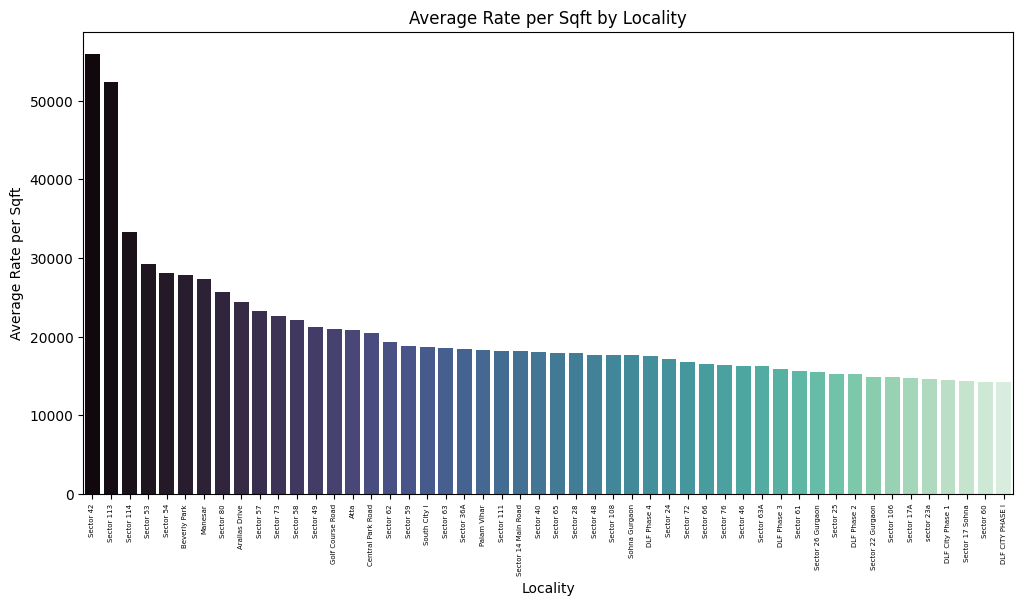

In [120]:
rate_per_sqft_by_locality=df.groupby('locality')['rate_per_sqft'].mean().sort_values(ascending=False).head(50)
plt.figure(figsize=(12,6))
sns.barplot(x=rate_per_sqft_by_locality.index,y=rate_per_sqft_by_locality.values,palette='mako')
plt.xticks(rotation=90,fontsize=5)
plt.title('Average Rate per Sqft by Locality')
plt.xlabel('Locality')  
plt.ylabel('Average Rate per Sqft')
plt.show()

Which builder sells most expensive properties

In [121]:
df.groupby('builder_name')['price'].mean().sort_values(ascending=False).head(10)


builder_name
Harish                         221100000.0
India Gold Properties          203837500.0
Bob vennikal                   185000000.0
Vinit tomar                    183585000.0
Arihant prime realtors         180000000.0
Dream Home Realty              173337500.0
AMAYA Landbase                 168250000.0
Jagdish Estate                 154100000.0
GharDekhoCo               150783333.333333
JP Groups                      150000000.0
Name: price, dtype: Float64

Does approval status increase property value

In [122]:
df.head()

,price,status,area,rate_per_sqft,property_type,locality,builder_name,rera_approval,bhk_count,society,company_name,flat_type
0,10700000,Under Construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,True,2,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000,Under Construction,1528,9450,3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,True,3,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000,Under Construction,1138,9450,2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,True,2,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000,Ready to move,4500,8888,4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,False,4,Outside Socity,Outside,Plot
4,24000000,Under Construction,1800,13333,3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,True,3,Anant Raj Estate Plots,Anant,Floor


In [123]:
df.groupby('rera_approval')['price'].median()

rera_approval
False    25800000.0
True     27100000.0
Name: price, dtype: Float64

C:\Users\DELL\AppData\Local\Temp\ipykernel_10308\3173076957.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rera_approval',y='price',data=df,palette='Set2')


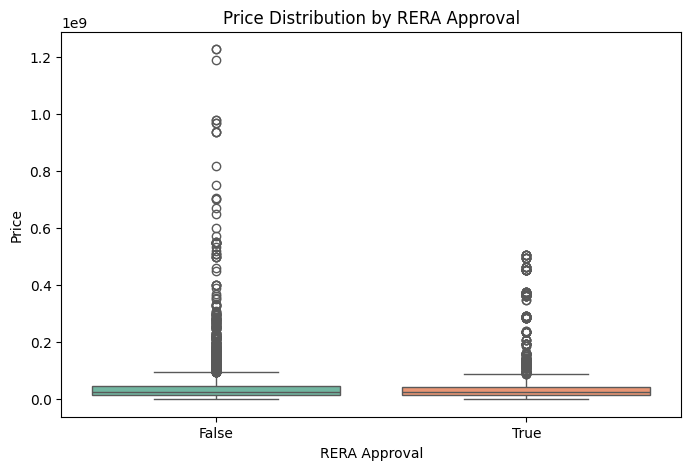

In [124]:
plt.figure(figsize=(8,5))
sns.boxplot(x='rera_approval',y='price',data=df,palette='Set2')
plt.title('Price Distribution by RERA Approval')    
plt.xlabel('RERA Approval')
plt.ylabel('Price')
plt.show()


which flat type is most demanded

In [125]:
most_demanded_flat=df['flat_type'].value_counts()
most_demanded_flat

flat_type
Apartment    10894
Plot          2166
Floor          881
Villa          205
House           45
Penthouse       32
Name: count, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_10308\3800854437.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_demanded_flat.index, y=most_demanded_flat.values, palette='dark')


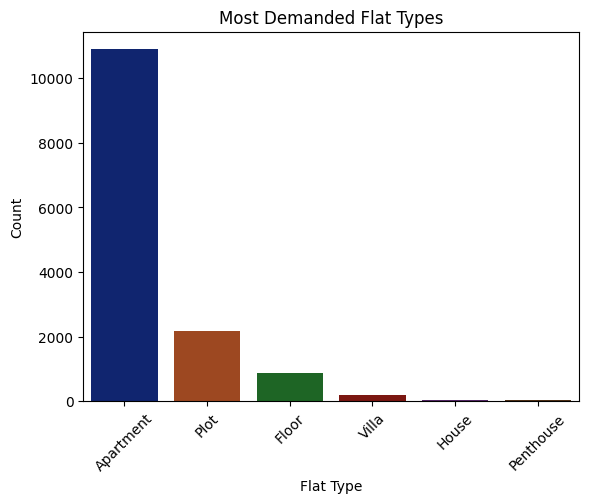

In [ ]:
sns.barplot(x=most_demanded_flat.index, y=most_demanded_flat.values, palette='dark')
plt.title('Most Demanded Flat Types')
plt.xlabel('Flat Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

How does area impact price

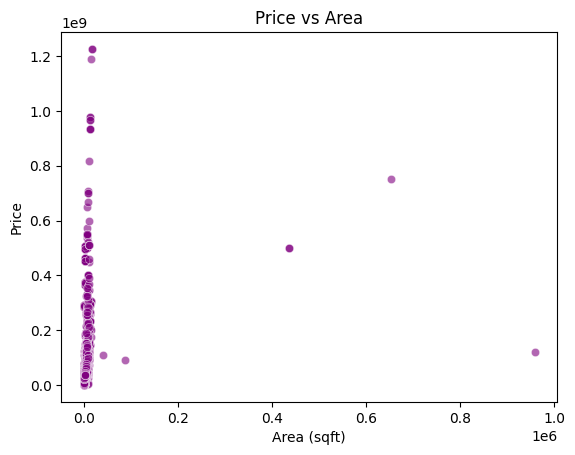

In [134]:
sns.scatterplot(x='area',y='price',data=df,color='purple',alpha=0.6)
plt.title('Price vs Area')  
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.show()

conclusion: Scatter plot suggest that property price is not strongly dependent on area,as data points are widely dispersed on area, as data points are widely dispered without a clear trend.

Bhk vs price

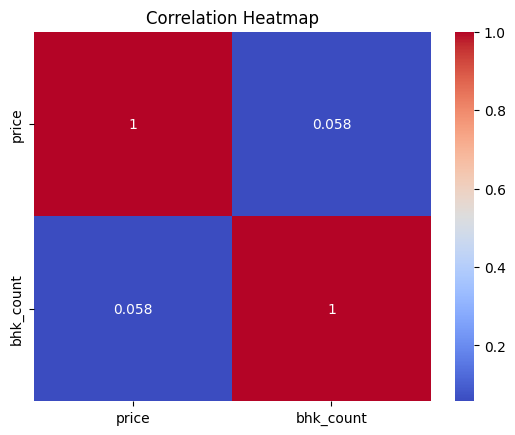

In [149]:
sns.heatmap(df[['price','bhk_count']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

 conclusion: Increasing the number of BHK does not significantly affect the property price

Final insights Summary:
1. Premium Localities consistently show higher prices 
2. rera -approval properties trend to command higher prices
3. larger homes are not always more expensive per sqft
4. Aparment generally have higher rate per sqft than plot and floors
5. Incrasing the number of bhk not affect the price